In [1]:
# Import necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import seaborn as sns

from sqlalchemy import create_engine
from urllib.parse import quote_plus

%matplotlib inline
matplotlib.rcParams['figure.figsize']=(12,8) 

In [2]:
# load data into DataFrame

df=pd.read_csv('customer_behavior.csv')

## Initial Exploratory Analysis

In [3]:
# view of dataset structure
print(f'number of rows:{df.shape[0]}\nnumber of columns:{df.shape[1]}')
print('-'*50)
df.head()


number of rows:5050
number of columns:18
--------------------------------------------------


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [4]:
# overview of data structure and types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             5050 non-null   int64  
 1   Age                     5050 non-null   int64  
 2   Gender                  5050 non-null   object 
 3   Item Purchased          5050 non-null   object 
 4   Category                5050 non-null   object 
 5   Purchase Amount (USD)   5050 non-null   int64  
 6   Location                5050 non-null   object 
 7   Size                    5050 non-null   object 
 8   Color                   5050 non-null   object 
 9   Season                  5050 non-null   object 
 10  Review Rating           5003 non-null   float64
 11  Subscription Status     5050 non-null   object 
 12  Shipping Type           5050 non-null   object 
 13  Discount Applied        5050 non-null   object 
 14  Promo Code Used         5050 non-null   

In [5]:
# Summary statistics of all columns
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,5050.00000,5050.000000,5050,5050,5050,5050.000000,5050,5050,5050,5050,5003.000000,5050,5050,5050,5050,5050.000000,5050,5050
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Idaho,M,Yellow,Spring,NaN,No,Standard,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,3404,237,2250,NaN,131,2286,234,1282,NaN,3695,886,2882,2882,NaN,887,748
mean,2525.50000,44.052871,NaN,NaN,NaN,59.673267,NaN,NaN,NaN,NaN,3.758365,NaN,NaN,NaN,NaN,25.381782,NaN,NaN
std,1457.95376,15.220860,NaN,NaN,NaN,23.629866,NaN,NaN,NaN,NaN,0.716379,NaN,NaN,NaN,NaN,14.481273,NaN,NaN
min,1.00000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,1263.25000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,2525.50000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,3787.75000,57.000000,NaN,NaN,NaN,80.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [6]:
# checking for attribute relationships
# hypothesis 1: review rating and purchase amount have a strong relationship
df.corr(method='pearson',numeric_only=True)

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
Customer ID,1.000000,-0.006188,-0.000294,0.015704,-0.019316
Age,-0.006188,1.000000,-0.009099,-0.024501,0.035311
Purchase Amount (USD),-0.000294,-0.009099,1.000000,0.033410,0.017748
Review Rating,0.015704,-0.024501,0.033410,1.000000,0.018312
Previous Purchases,-0.019316,0.035311,0.017748,0.018312,1.000000


In [7]:
# hypothesis 1: False
# hypothesis 2: payment method, prevous purchaeses and purchase frequency may be ralated

# convert categorical columns to numeric for correlation analysis
df_numeric= df.copy()

for col_name in df_numeric.columns:
    if(df_numeric[col_name].dtype =='object'):
        df_numeric[col_name]=df_numeric[col_name].astype('category').cat.codes

df_numeric.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,1,2,1,53,16,0,7,3,3.1,1,1,1,1,14,5,3
1,2,19,1,23,1,64,18,0,12,3,3.1,1,1,1,1,2,1,3
2,3,50,1,11,1,73,20,2,12,1,3.1,1,2,1,1,23,2,6
3,4,21,1,14,2,90,38,1,12,1,3.5,1,3,1,1,49,4,6
4,5,45,1,2,1,49,36,1,21,1,2.7,1,2,1,1,31,4,0


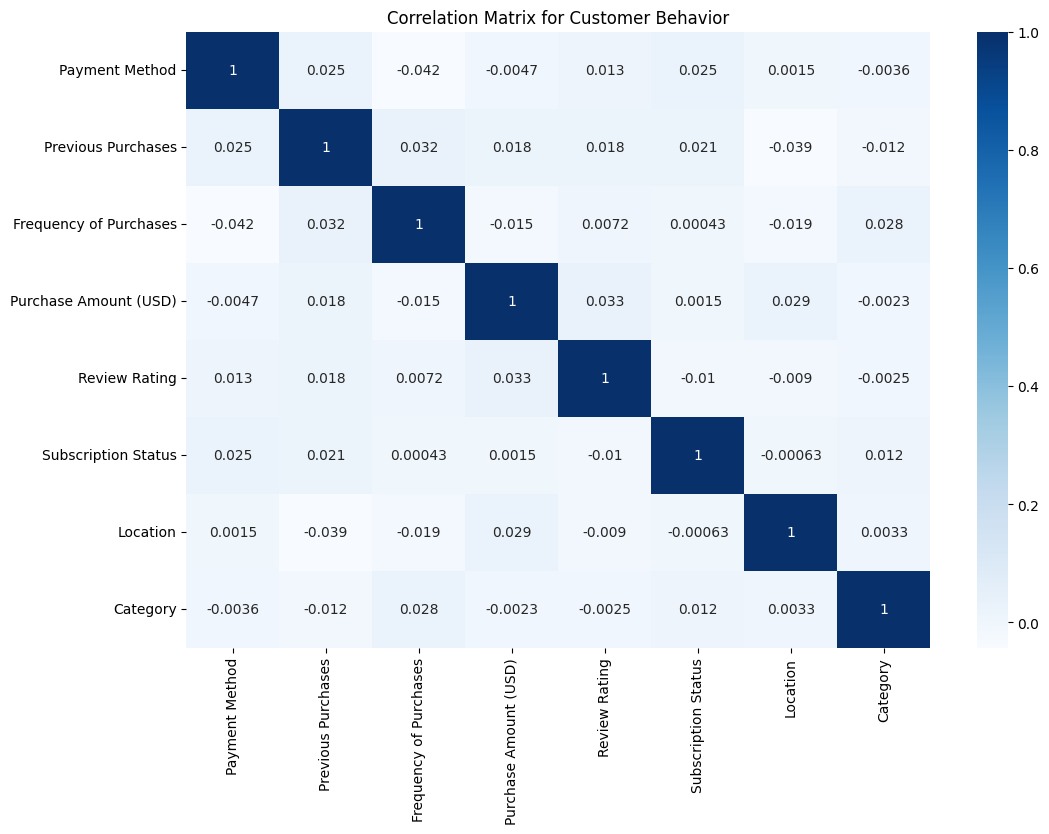

In [8]:
filtered_df=df_numeric[[
    'Payment Method','Previous Purchases','Frequency of Purchases',
    'Purchase Amount (USD)','Review Rating', 'Subscription Status',
    'Location','Category'
    ]]
corr_matirx=filtered_df.corr(method='pearson')

sns.heatmap(corr_matirx,annot=True, cmap='Blues')
plt.title('Correlation Matrix for Customer Behavior')
plt.show()

#hypothesis 2: False

In [9]:
# Checking for missing values

def missing_values(df1):
    df_null = pd.DataFrame({
        'Columnn name':df1.columns,
        'Null values':df1.isnull().sum(),
        'Null percetage(%)': (df1.isnull().sum()/len(df1)*100).round(2)
    }).sort_values('Null percetage(%)', ascending=False)
    print(df_null)

missing_values(df)

                                  Columnn name  Null values  Null percetage(%)
Review Rating                    Review Rating           47               0.93
Customer ID                        Customer ID            0               0.00
Age                                        Age            0               0.00
Payment Method                  Payment Method            0               0.00
Previous Purchases          Previous Purchases            0               0.00
Promo Code Used                Promo Code Used            0               0.00
Discount Applied              Discount Applied            0               0.00
Shipping Type                    Shipping Type            0               0.00
Subscription Status        Subscription Status            0               0.00
Season                                  Season            0               0.00
Color                                    Color            0               0.00
Size                                      Size      

## Data Cleaning and Preparation

columns to be worked on
1. missing values in Review rating (0.93% of the data missing)
2. column name cleaning (mixed cases and spaces)
3. rename 'Purchase Amount (USD)' to just purchase amount
4. Engineer new features for analysis (age grouping)
5. map Purcahes frequency days to numeric representations
6. check for duplicate rows and columns
7. check final data distribution


to prevent bias across all categories of the data when filling in review rating,
each empty value category is replaced with the median of its respectice category

In [10]:
# 1. Filling missing Review Rating values

df['Review Rating']=df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))
print('Applied')
print('_'*50)
missing_values(df)

Applied
__________________________________________________
                                  Columnn name  Null values  Null percetage(%)
Customer ID                        Customer ID            0                0.0
Age                                        Age            0                0.0
Payment Method                  Payment Method            0                0.0
Previous Purchases          Previous Purchases            0                0.0
Promo Code Used                Promo Code Used            0                0.0
Discount Applied              Discount Applied            0                0.0
Shipping Type                    Shipping Type            0                0.0
Subscription Status        Subscription Status            0                0.0
Review Rating                    Review Rating            0                0.0
Season                                  Season            0                0.0
Color                                    Color            0             

In [11]:
# 2. Column name Cleaning
# 3. rename purchase amount

df.columns =df.columns.str.lower()
df.columns=df.columns.str.replace(' ','_')
df=df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})
print('Applied')
print('_'*50)
df.columns


Applied
__________________________________________________


Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [12]:
# 4. New Feature Creation: Age group
# using interquartile ranges to create age groups

labels=['Young Adult','Adult','Middle Aged','Senior']
df['age_group']=pd.qcut(df['age'],q=4,labels=labels)
print('Applied')
print('_'*50)
df[['customer_id','age','age_group']].head()

Applied
__________________________________________________


,customer_id,age,age_group
0,1,55,Middle Aged
1,2,19,Young Adult
2,3,50,Middle Aged
3,4,21,Young Adult
4,5,45,Middle Aged


In [13]:
# 5. New Feature Creation: Purchase frequency days
# mapping english terms to respective numerical values

frequency_mapping={
    'Weekly': 7,
    'Bi-Weekly': 14,
    'Fortnightly': 14,
    'Monthly': 30,
    'Every 3 Months':90,
    'Quarterly': 90,
    'Annually': 365
}

df['purchase_frequency_days']=df['frequency_of_purchases'].map(frequency_mapping)
print('Applied')
print('_'*50)
df[['customer_id','purchase_frequency_days','frequency_of_purchases']].head()

Applied
__________________________________________________


,customer_id,purchase_frequency_days,frequency_of_purchases
0,1,14,Fortnightly
1,2,14,Fortnightly
2,3,7,Weekly
3,4,7,Weekly
4,5,365,Annually


In [14]:
# 6. checking for duplicate records

duplicate_count=df.duplicated().sum()
print(f'Number of duplicate records: {duplicate_count}')

# discount_applied and promo code used columns appear to have the same information
print('Both columns have the same information:', (df['promo_code_used'] == df['discount_applied']).all())

Number of duplicate records: 0
Both columns have the same information: True


In [15]:
# dropping promo code used column
df.drop('promo_code_used', axis=1, inplace=True)
print('Applied')
print('_'*50)
print(f'new column count: {len(df.columns)}')
df.columns

Applied
__________________________________________________
new column count: 19


Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='object')

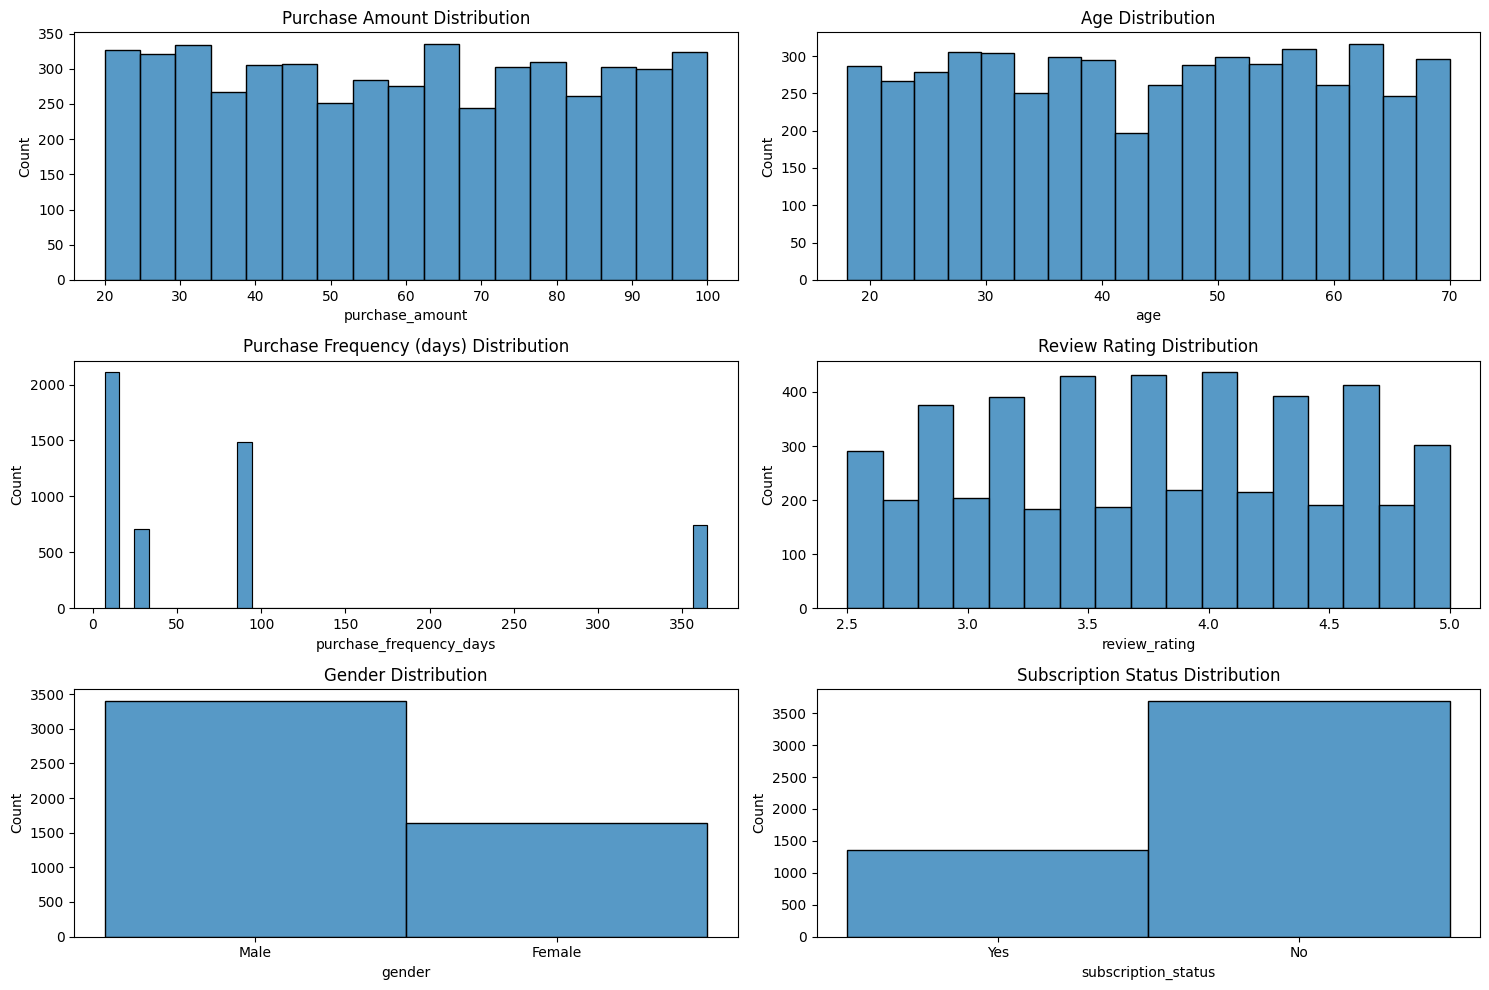

In [17]:
# data distribution analysis
fig,axes =plt.subplots(3,2,figsize=(15,10))
sns.histplot(df['purchase_amount'],ax=axes[0,0])
axes[0,0].set_title('Purchase Amount Distribution')
sns.histplot(df['age'],ax=axes[0,1])
axes[0,1].set_title('Age Distribution')
sns.histplot(df['purchase_frequency_days'],ax=axes[1,0])
axes[1,0].set_title('Purchase Frequency (days) Distribution')
sns.histplot(df['review_rating'],ax=axes[1,1])
axes[1,1].set_title('Review Rating Distribution')
sns.histplot(df['gender'],ax=axes[2,0])
axes[2,0].set_title('Gender Distribution')
sns.histplot(df['subscription_status'],ax=axes[2,1])
axes[2,1].set_title('Subscription Status Distribution')
plt.tight_layout()
plt.show()

## Data Base Connection Setup

In [ ]:
# Connecting to MySQL server

username= 'root'
password= '***********'
host= '127.0.0.1'
port='3306'
database='Customers_Behavior'

# safe password encoding
safe_password=quote_plus(password)

# create connection string
engine= create_engine(f'mysql+pymysql://{username}:{safe_password}@{host}:{port}/{database}')

# write DataFrame to MySQL database
table_name='customers'
df.to_sql(table_name,engine,if_exists='replace',index=False)

# verify data insertion
pd.read_sql(f'SELECT * FROM {table_name} LIMIT 5;', engine)